In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
from matplotlib import pyplot as plt
from scipy import stats

sns.set()

In [2]:
# base_dir = '/home/shiva/Datasets/Euroc_Datasets'
# working_dir = 'V2_01_easy/mav0/imu0'

# df_imu = pd.read_csv(f'{base_dir}/{working_dir}/data.csv')

In [8]:
base_dir = '/home/shiva/Datasets/Custom_Datasets'
working_dir = 'No_Movement/mav0'

df_imu = pd.read_csv(f'{base_dir}/{working_dir}/imu0/data.csv')

FileNotFoundError: [Errno 2] No such file or directory: '/home/shiva/Datasets/Custom_Datasets/y_axis_forward_v2_updated_noise_params/imu0/data.csv'

In [ ]:
df_imu.head(5)

In [ ]:
df_imu.rename(columns={"#timestamp [ns]": "timestamp_[ns]"}, inplace=True)

In [ ]:
cols = df_imu.columns

In [4]:
cols

NameError: name 'cols' is not defined

NameError: name 'df_imu' is not defined

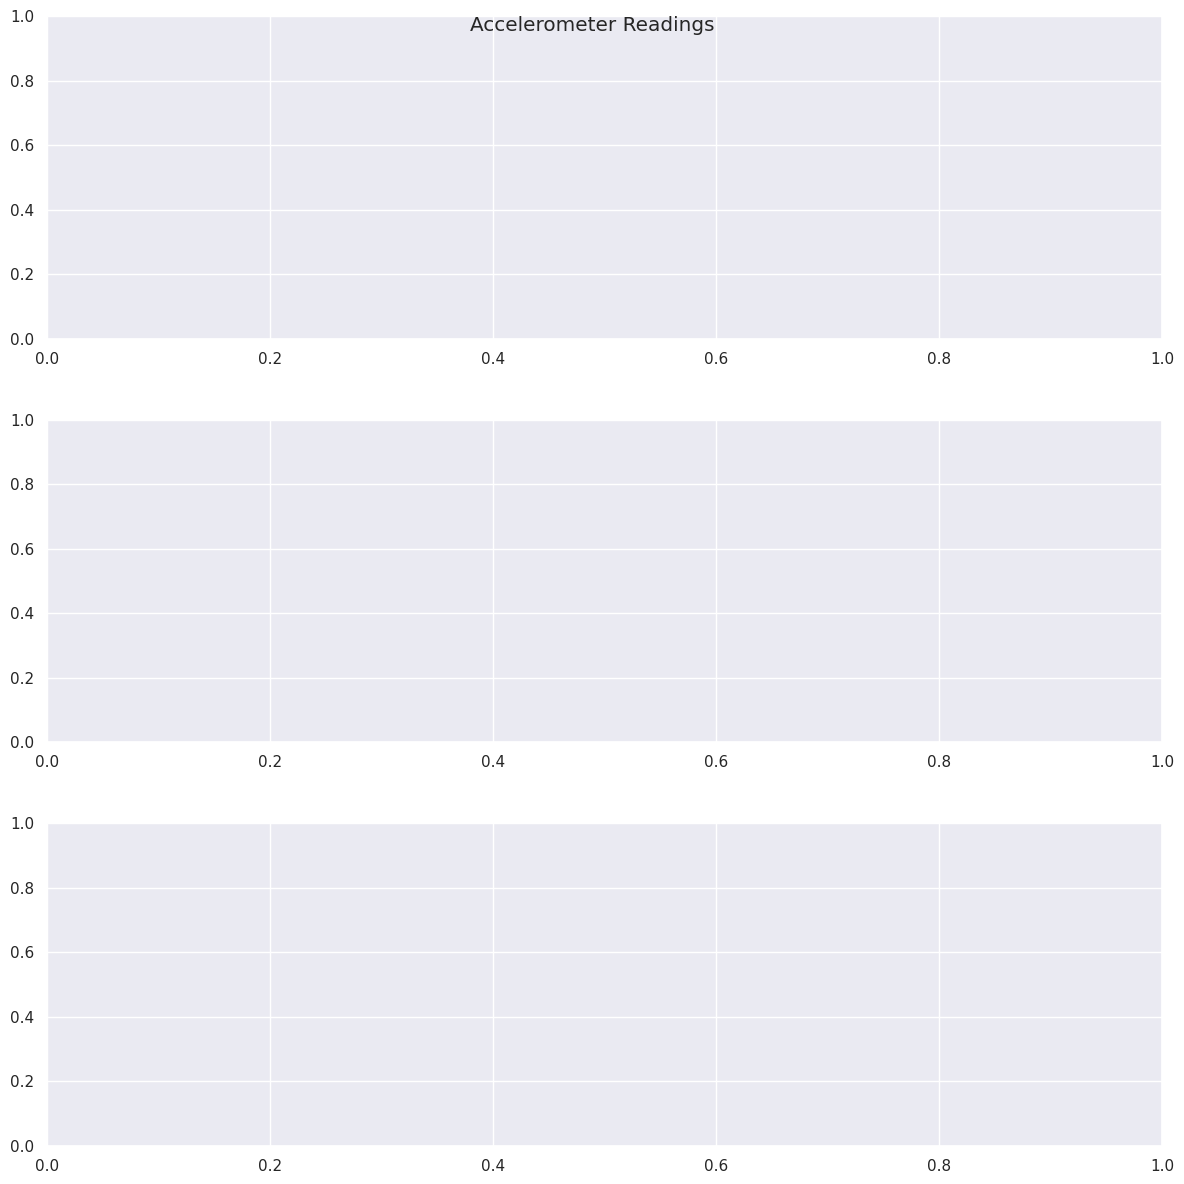

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharey=True)
fig.tight_layout()
plt.subplots_adjust(hspace=0.25)
fig.suptitle('Accelerometer Readings')

# Bulbasaur
sns.lineplot(ax=axes[0], x=df_imu[cols[0]], y=df_imu[cols[4]])
axes[0].set_title('X')

# Charmander
sns.lineplot(ax=axes[1], x=df_imu[cols[0]], y=df_imu[cols[5]])
axes[1].set_title('Y')

# Squirtle
sns.lineplot(ax=axes[2], x=df_imu[cols[0]], y=df_imu[cols[6]])
axes[2].set_title('Z')

### Investigating at specific time point

In [9]:
start_ts = 1741631562271405056
end_ts = 1741631572121402880

In [10]:
df_imu_filtered = df_imu.query(f"`{cols[0]}`>={start_ts} & `{cols[0]}`<={end_ts}")

In [11]:
df_imu_filtered.head(5)

,timestamp_[ns],w_RS_S_x [rad s^-1],w_RS_S_y [rad s^-1],w_RS_S_z [rad s^-1],a_RS_S_x [m s^-2],a_RS_S_y [m s^-2],a_RS_S_z [m s^-2]
1076,1741631562272178944,-0.000000,-0.005326,-0.002131,-9.62616,-0.22984,-1.16910
1077,1741631562277238016,-0.000000,-0.001065,-0.002131,-9.66300,-0.24169,-1.15148
1078,1741631562282318080,-0.006392,-0.004261,0.002131,-9.65684,-0.23669,-1.16495
1079,1741631562287683072,0.004261,-0.005326,0.002131,-9.65813,-0.23456,-1.17308
1080,1741631562292294912,-0.000000,-0.003196,0.001065,-9.66300,-0.24170,-1.17909


In [14]:
df_imu_filtered.shape

(1971, 7)

In [15]:
df_imu_filtered.describe()

,timestamp_[ns],w_RS_S_x [rad s^-1],w_RS_S_y [rad s^-1],w_RS_S_z [rad s^-1],a_RS_S_x [m s^-2],a_RS_S_y [m s^-2],a_RS_S_z [m s^-2]
count,1.971000e+03,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000,1971.000000
mean,1.741632e+18,0.000189,-0.003576,0.000329,-9.664847,-0.244709,-1.161870
std,2.845007e+09,0.003369,0.002494,0.002717,0.016915,0.015179,0.017188
min,1.741632e+18,-0.011718,-0.011718,-0.009587,-9.737930,-0.293680,-1.232950
25%,1.741632e+18,-0.002131,-0.005326,-0.001065,-9.675500,-0.254925,-1.173335
50%,1.741632e+18,0.000000,-0.003196,0.000000,-9.664360,-0.244250,-1.161660
75%,1.741632e+18,0.002131,-0.002131,0.002131,-9.653420,-0.235050,-1.150115
max,1.741632e+18,0.010653,0.006392,0.009587,-9.605540,-0.190210,-1.104840


Text(0.5, 1.0, 'Z')

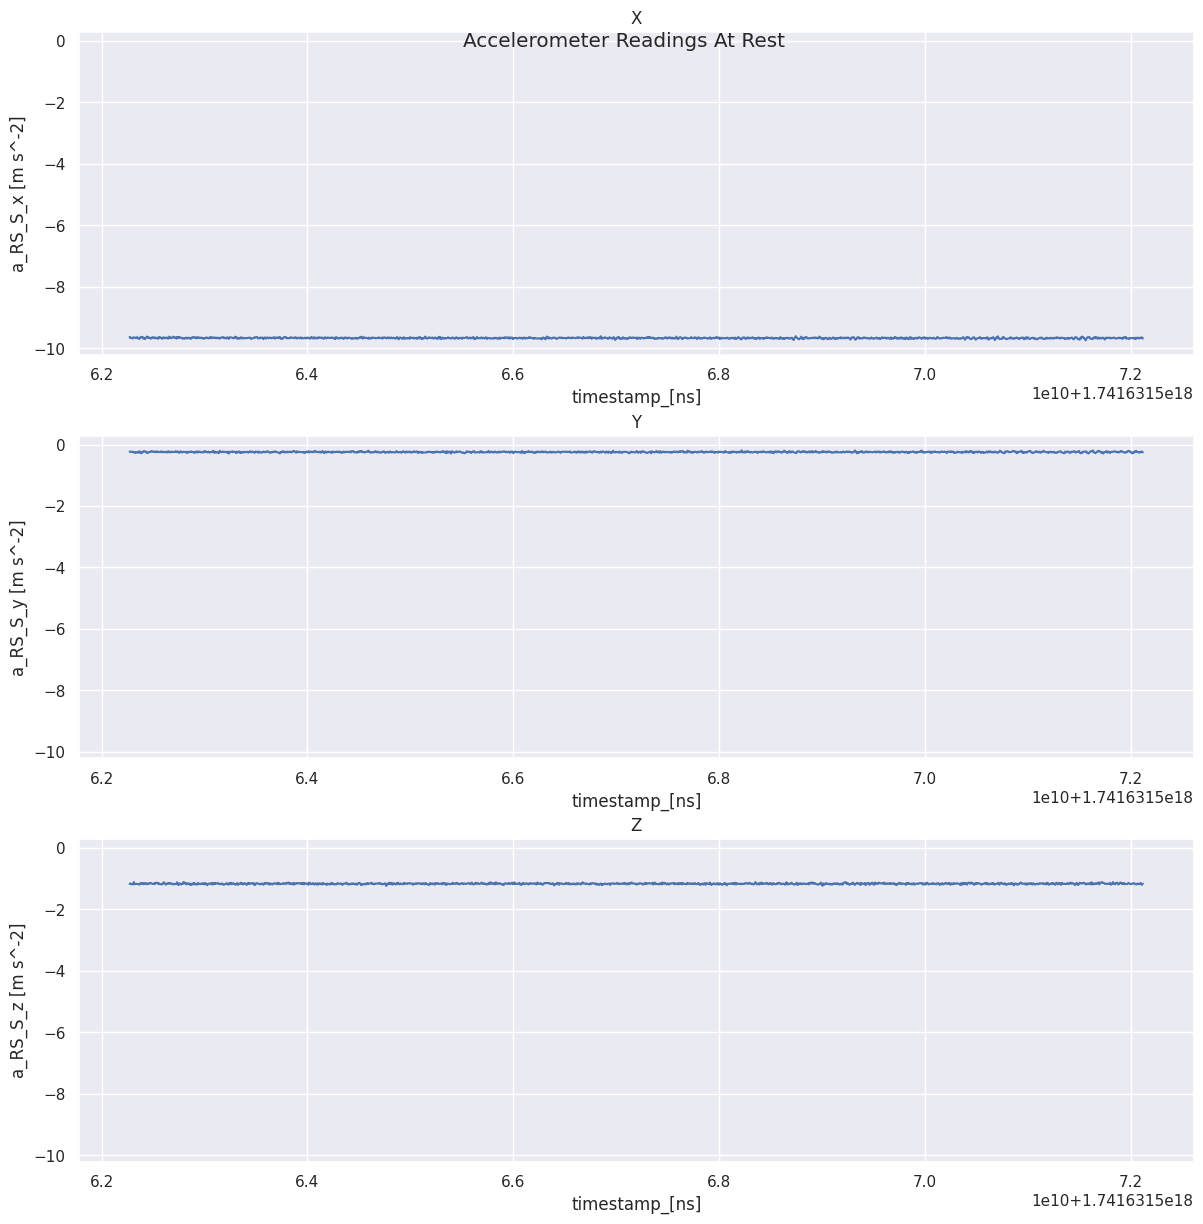

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharey=True)
fig.tight_layout()
plt.subplots_adjust(hspace=0.25)
fig.suptitle('Accelerometer Readings At Rest')

# Bulbasaur
sns.lineplot(ax=axes[0], x=df_imu_filtered[cols[0]], y=df_imu_filtered[cols[4]])
axes[0].set_title('X')

# Charmander
sns.lineplot(ax=axes[1], x=df_imu_filtered[cols[0]], y=df_imu_filtered[cols[5]])
axes[1].set_title('Y')

# Squirtle
sns.lineplot(ax=axes[2], x=df_imu_filtered[cols[0]], y=df_imu_filtered[cols[6]])
axes[2].set_title('Z')

<Axes: xlabel='timestamp_[ns]', ylabel='a_RS_S_x [m s^-2]'>

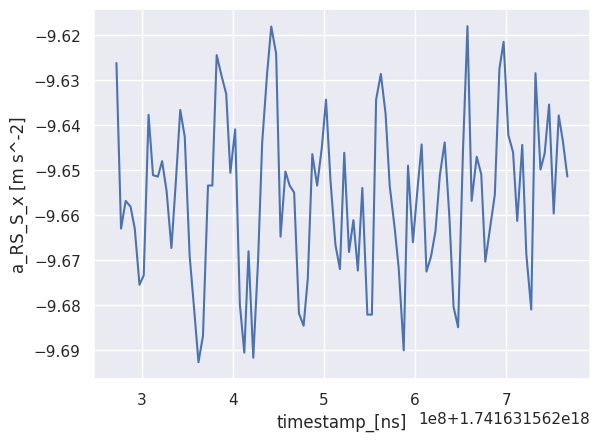

In [17]:
sns.lineplot(data=df_imu_filtered[0:100], x=cols[0], y=cols[4])

In [18]:
#Subtracting mean to expose noise.
for col in cols[1:]:
    df_imu_filtered[col] = df_imu_filtered[col] - df_imu_filtered[col].mean()

/tmp/ipykernel_41765/2764248637.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_imu_filtered[col] = df_imu_filtered[col] - df_imu_filtered[col].mean()


<Axes: xlabel='timestamp_[ns]', ylabel='a_RS_S_x [m s^-2]'>

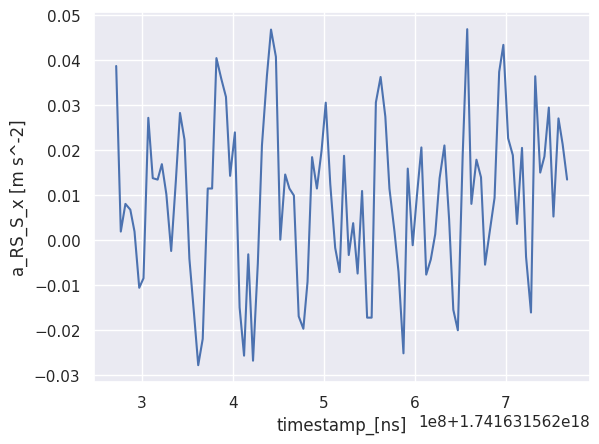

In [19]:
sns.lineplot(data=df_imu_filtered[0:100], x=cols[0], y=cols[4])

<Axes: xlabel='timestamp_[ns]', ylabel='a_RS_S_x [m s^-2]'>

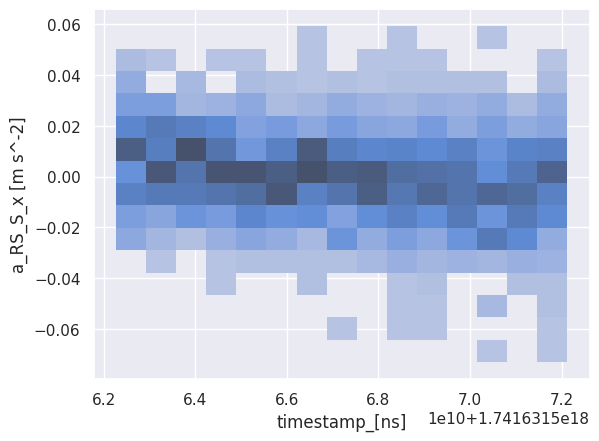

In [20]:
sns.histplot(data=df_imu_filtered, x=cols[0], y=cols[4], bins=15)

In [27]:
for col in cols[1:]:
    print(f"Statistical test for {col}.")
    # If the p-value is less than a significance level (e.g., 0.05), you reject the null hypothesis 
    # and conclude that your data does not follow the hypothesized distribution.  
    # print("", stats.kstest(df_imu_filtered[col], stats.norm.cdf))
    # print("", stats.shapiro(df_imu_filtered[col]))
    print("", sm.stats.acorr_ljungbox(df_imu_filtered[col], lags=10))
    print("\n")

Statistical test for w_RS_S_x [rad s^-1].
       lb_stat  lb_pvalue
1    1.543252   0.214134
2    9.203302   0.010035
3   10.148948   0.017342
4   10.438182   0.033659
5   10.441885   0.063640
6   10.653397   0.099698
7   11.574886   0.115434
8   11.855362   0.157775
9   12.451210   0.189050
10  12.452387   0.255920


Statistical test for w_RS_S_y [rad s^-1].
       lb_stat  lb_pvalue
1    1.389023   0.238570
2    1.958873   0.375523
3    2.762507   0.429709
4    4.223418   0.376613
5    6.341767   0.274369
6    7.559522   0.272181
7    9.436198   0.222837
8   10.747606   0.216414
9   15.051284   0.089537
10  15.317994   0.120891


Statistical test for w_RS_S_z [rad s^-1].
       lb_stat     lb_pvalue
1   24.788125  6.399048e-07
2   27.222235  1.226780e-06
3   27.351324  4.968803e-06
4   27.784143  1.379448e-05
5   28.017894  3.610676e-05
6   28.022893  9.303454e-05
7   30.392929  8.042448e-05
8   31.229785  1.278678e-04
9   31.261887  2.669119e-04
10  31.279506  5.274919e-04


Statist